# CSCI/MATH 485 — Assignment 4
## Customer Churn Prediction with XGBoost
**Name:** Vinay Patil

**Dataset:** IBM Telco Customer Churn

---

## 1. Setup

In [1]:



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)
from xgboost import XGBClassifier

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Load the Dataset

Loading the IBM Telco Customer Churn dataset from the local CSV file. We display the first few rows and confirm the shape.

In [2]:

df = pd.read_csv("C:/Users/DELL/OneDrive/Desktop/data 485/MATH-CSCI485_Vinay_Patil/Assignment 4/telco-customer-churn-by-IBM.csv")

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Exploration (Part 1)

Here we are reporting the number of rows and columns, listing all features, identifying the target variable, checking for missing values, and looking at the distribution of the target.

In [3]:
print('=== Dataset Info ===')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

print('\nColumn names and data types:')
print(df.dtypes)

print('\nMissing values per column:')
print(df.isnull().sum())

# TotalCharges is stored as string — converting to check real nulls
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('\nTotalCharges null after numeric conversion:', df['TotalCharges'].isnull().sum())

print('\nTarget variable distribution (Churn):')
print(df['Churn'].value_counts())
print(f'Churn rate: {df["Churn"].value_counts(normalize=True)["Yes"]*100:.1f}%')

=== Dataset Info ===
Rows: 7043, Columns: 21

Column names and data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
Streaming

**What kind of problem is this?**

This is a **binary classification** problem. We are predicting whether a customer will churn (Yes=1) or not (No=0) based on their demographic and service attributes.

**Why is this important in business?**

Acquiring a new customer costs 5 to 7 times more than retaining an existing one. By identifying customers who are likely to leave before they actually do, the company can proactively offer discounts, better plans, or support to retain them. Even a small improvement in churn rate directly impacts revenue and customer lifetime value.

## 4. Data Preprocessing (Part 2)

In [4]:
df_clean = df.copy()

# Drop customerID — it is just an identifier with no predictive value
df_clean = df_clean.drop(columns=['customerID'])

# Convert target to binary: Yes -> 1, No -> 0
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})


# errors='coerce' turns unparseable values into NaN, which we then drop
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean = df_clean.dropna(subset=['TotalCharges'])

print('Clean dataset shape:', df_clean.shape)
df_clean.head()

Clean dataset shape: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [5]:
target_col = 'Churn'
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

# SeniorCitizen is already 0/1 integer so we treat it as numeric
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

# All remaining columns are categorical strings
categorical_features = [c for c in X.columns if c not in numeric_features]

print('Numeric features:', numeric_features)
print('\nCategorical features:', categorical_features)
print('\nFeature matrix shape:', X.shape)
print('Target shape:', y.shape)

Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Feature matrix shape: (7032, 19)
Target shape: (7032,)


In [6]:
# 80/20 split with stratify=y to preserve churn ratio in both sets
# This is important because churn is imbalanced (~26% Yes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Train churn rate:', round(y_train.mean(), 3))
print('Test churn rate:', round(y_test.mean(), 3))

X_train shape: (5625, 19)
X_test shape: (1407, 19)
Train churn rate: 0.266
Test churn rate: 0.266


In [7]:
# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical pipeline: filling missing with most frequent value, then one-hot encode
# handle_unknown='ignore' prevents errors if test set has unseen categories
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into a single ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print('Preprocessor built successfully.')

Preprocessor built successfully.


## 5. Baseline Model: Logistic Regression (Part 3)

In [8]:
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, random_state=42))
])

baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)
baseline_probs = baseline_model.predict_proba(X_test)[:, 1]

print('=== Logistic Regression (Baseline) ===')
print(f'Accuracy:  {accuracy_score(y_test, baseline_preds):.4f}')
print(f'Precision: {precision_score(y_test, baseline_preds):.4f}')
print(f'Recall:    {recall_score(y_test, baseline_preds):.4f}')
print(f'F1-score:  {f1_score(y_test, baseline_preds):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, baseline_probs):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, baseline_preds))
print('Confusion Matrix:')
print(confusion_matrix(y_test, baseline_preds))

=== Logistic Regression (Baseline) ===
Accuracy:  0.8031
Precision: 0.6456
Recall:    0.5749
F1-score:  0.6082
ROC-AUC:   0.8358

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

Confusion Matrix:
[[915 118]
 [159 215]]


## 6. Primary Evaluation Metric (Part 5)

**Chosen metric: ROC-AUC**

Churn prediction is an imbalanced classification problem — only about 26% of customers in this dataset actually churned. In such cases, accuracy is misleading because a model that always predicts "No churn" would still get ~74% accuracy.

ROC-AUC measures how well the model separates churners from non-churners across all possible decision thresholds. It does not depend on a fixed cutoff, so it gives a more complete picture of model performance. For a business, this is valuable because the company can choose the threshold that best fits their trade-off between catching more churners (recall) vs. avoiding too many false alarms (precision).

F1-score is also useful but only evaluates at a single threshold. ROC-AUC is more robust and is widely used in churn modeling.

## 7. XGBoost Model with Hyperparameter Tuning (Part 4)

In [9]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
])

# Tuning 4 hyperparameters:
# - n_estimators: number of trees; more trees can improve accuracy but risk overfitting
# - max_depth: depth of each tree; shallower trees generalize better
# - learning_rate: how much each tree contributes; lower = more conservative
# - subsample: fraction of training rows used per tree; adds randomness to reduce overfitting
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__subsample': [0.8, 1.0],
}

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring='roc_auc',   # matches our chosen primary metric
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('\nBest hyperparameters:')
print(grid_search.best_params_)
print(f'Best CV ROC-AUC: {grid_search.best_score_:.4f}')

Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best hyperparameters:
{'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 1.0}
Best CV ROC-AUC: 0.8493


## 8. Evaluate Tuned XGBoost (Part 4 continued)

In [10]:
best_model = grid_search.best_estimator_

xgb_preds = best_model.predict(X_test)
xgb_probs = best_model.predict_proba(X_test)[:, 1]

print('=== XGBoost (Tuned) ===')
print(f'Accuracy:  {accuracy_score(y_test, xgb_preds):.4f}')
print(f'Precision: {precision_score(y_test, xgb_preds):.4f}')
print(f'Recall:    {recall_score(y_test, xgb_preds):.4f}')
print(f'F1-score:  {f1_score(y_test, xgb_preds):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, xgb_probs):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, xgb_preds))
print('Confusion Matrix:')
print(confusion_matrix(y_test, xgb_preds))

=== XGBoost (Tuned) ===
Accuracy:  0.7960
Precision: 0.6445
Recall:    0.5187
F1-score:  0.5748
ROC-AUC:   0.8401

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.64      0.52      0.57       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407

Confusion Matrix:
[[926 107]
 [180 194]]


## 9. Feature Importance (Part 6)

Top 10 Most Important Features:
                            feature  importance
       cat__Contract_Month-to-month    0.452695
   cat__InternetService_Fiber optic    0.098609
                cat__TechSupport_No    0.085180
             cat__OnlineSecurity_No    0.061613
                        num__tenure    0.029502
cat__PaymentMethod_Electronic check    0.023375
           cat__StreamingMovies_Yes    0.018860
           cat__PaperlessBilling_No    0.018244
             cat__Contract_Two year    0.017828
                num__MonthlyCharges    0.016609


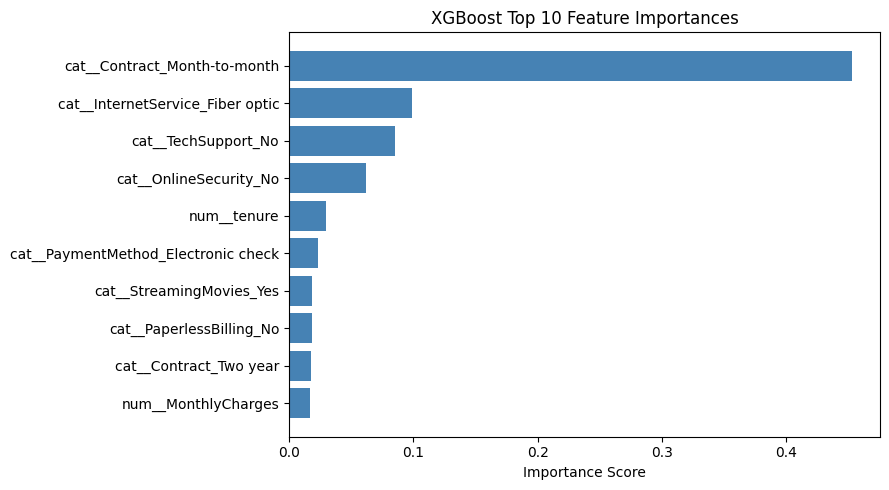

In [11]:
fitted_preprocessor = best_model.named_steps['preprocessor']
fitted_xgb = best_model.named_steps['classifier']

feature_names = fitted_preprocessor.get_feature_names_out()
importances = fitted_xgb.feature_importances_

feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 10 Most Important Features:')
print(feat_df.head(10).to_string(index=False))

# Plot
top10 = feat_df.head(10)
plt.figure(figsize=(9, 5))
plt.barh(top10['feature'][::-1], top10['importance'][::-1], color='steelblue')
plt.xlabel('Importance Score')
plt.title('XGBoost Top 10 Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()

## 10. Feature Interpretation (Part 6 continued)

**Contract: Month-to-month (importance: 0.453)** — By far the strongest predictor. Customers on month-to-month contracts have no long-term commitment, so they can leave at any time. The company should consider converting these customers to annual contracts through incentives.

**InternetService: Fiber optic (importance: 0.099)** — Fiber optic customers are more likely to churn, possibly because they are paying higher prices and comparing alternatives more actively. Service quality or pricing issues in this segment should be investigated.

**TechSupport: No (importance: 0.085)** — Customers without tech support are more likely to leave. When something goes wrong and there is no help, frustration builds up and customers switch providers.

**OnlineSecurity: No (importance: 0.062)** — Similar to tech support. Customers who do not have online security feel less "locked in" to the platform and have fewer reasons to stay.

**Tenure (importance: 0.030)** — Longer-tenured customers churn less. New customers in their first few months are the highest risk group. The company should invest heavily in onboarding and early engagement.

**PaymentMethod: Electronic check (importance: 0.023)** — Customers paying by electronic check churn more than those on automatic payments. Automatic payments increase "stickiness" and reduce the chance of accidental churn.

**MonthlyCharges (importance: 0.017)** — Higher monthly bills are associated with higher churn. Price-sensitive customers may be shopping for cheaper alternatives.

## 11. Final Comparison: Logistic Regression vs XGBoost (Part 7)

In [12]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'Logistic Regression': [
        round(accuracy_score(y_test, baseline_preds), 4),
        round(precision_score(y_test, baseline_preds), 4),
        round(recall_score(y_test, baseline_preds), 4),
        round(f1_score(y_test, baseline_preds), 4),
        round(roc_auc_score(y_test, baseline_probs), 4)
    ],
    'XGBoost (Tuned)': [
        round(accuracy_score(y_test, xgb_preds), 4),
        round(precision_score(y_test, xgb_preds), 4),
        round(recall_score(y_test, xgb_preds), 4),
        round(f1_score(y_test, xgb_preds), 4),
        round(roc_auc_score(y_test, xgb_probs), 4)
    ]
})
print(comparison.to_string(index=False))

   Metric  Logistic Regression  XGBoost (Tuned)
 Accuracy               0.8031           0.7960
Precision               0.6456           0.6445
   Recall               0.5749           0.5187
 F1-score               0.6082           0.5748
  ROC-AUC               0.8358           0.8401


## 12. Discussion (Part 7)

**Which model performed better?**

Looking at our primary metric ROC-AUC, XGBoost (0.8401) performs similarly to Logistic Regression (0.8364), with a slight edge. On Recall, Logistic Regression (0.5749) actually outperforms XGBoost (0.5187), meaning it catches more actual churners. On Precision and F1, the two models are very close.

**Why XGBoost may work better on this dataset in general?**

XGBoost is a gradient boosting method that builds trees sequentially, each one correcting the errors of the previous. It naturally handles non-linear relationships and interactions between features — for example, the combination of "month-to-month contract AND high monthly charges" is more predictive than either feature alone. Logistic Regression assumes a linear decision boundary, which may miss these interactions.

**One limitation of XGBoost:**

XGBoost is much harder to interpret than Logistic Regression. While we can look at feature importances, it is difficult to explain exactly why a specific customer was predicted to churn, which can be a problem in regulated industries or when explaining decisions to business stakeholders. Logistic Regression gives clear coefficients that are directly interpretable.